In [ ]:
import numpy as np

from tools.circuits import generate_steane_circuit 
from tools.error_models import construct_circuit_noise_model 
from tools.log_error_rate import generate_log_error_rates_diff_p, count_logical_errors_ML , count_logical_errors_MWPM

In [2]:
import tools.graphics as graphic 
from importlib import reload
reload(graphic)

<module 'tools.graphics' from '/home/leo/Documents/MasterArbeit/code/tools/graphics.py'>

In [3]:
# Global Parameters
distances = [3,5]
rounds = 1
noise_set = np.logspace(-3,-0.9, num=15)

steane_circuits = [generate_steane_circuit(d,rounds=rounds) for d in distances]
noise_func = construct_circuit_noise_model
noise_model = "circ"


In [4]:
# ML
num_shots = 10_000
count_logical_func = count_logical_errors_ML

log_error_rates_ML, y_errs_ML = generate_log_error_rates_diff_p(
    steane_circuits,
    noise_func,
    count_log_error_fct=count_logical_func,
    distances= distances,
    noise_set= noise_set,
    num_shots= num_shots,
    rounds=rounds,
    noise_model=noise_model,
)

In [5]:
# MWPM
num_shots = 10_000
count_logical_func = count_logical_errors_MWPM 


log_error_rates_MWPM, y_errs_MWPM = generate_log_error_rates_diff_p(
    steane_circuits,
    noise_func,
    count_log_error_fct=count_logical_func,
    distances= distances,
    noise_set= noise_set,
    num_shots= num_shots,
    rounds=rounds,
    noise_model=noise_model,
)

/home/leo/Documents/MasterArbeit/code/tools/graphics.py:30: RuntimeWarning: divide by zero encountered in log
  y, x= clean_array(np.log(log_prob), np.log(noise))


<Figure size 640x480 with 0 Axes>

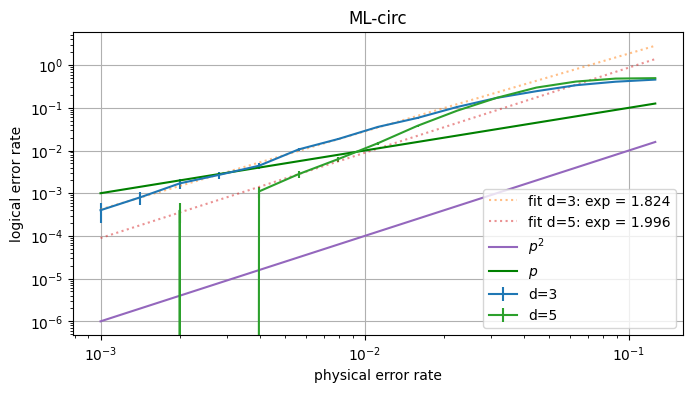

<Figure size 640x480 with 0 Axes>

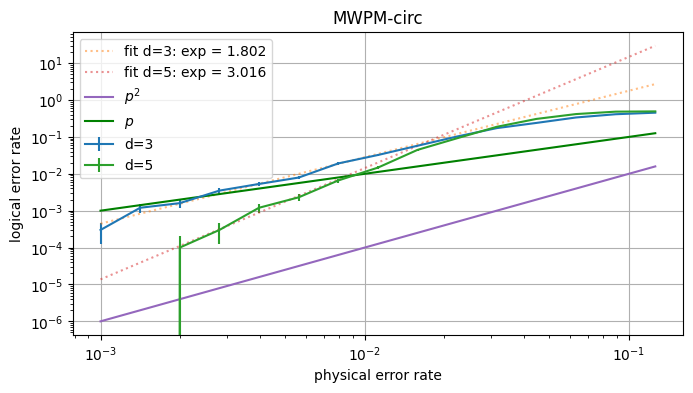

In [6]:
graphic.plot_diff_noise_level(
        log_error_rates_ML,
        y_errs_ML,
        distances,
        noise_set,
        fit_slopes = True,
        reference_lines = True,
        title="ML-circ"
    ) 
graphic.plot_diff_noise_level(
        log_error_rates_MWPM,
        y_errs_MWPM,
        distances,
        noise_set,
        fit_slopes = True,
        reference_lines = True,
        title="MWPM-circ"
    ) 